# EDA Analysis — Mutual Fund Analytics Platform
**Bluestock Fintech Capstone | Day 3**

Exploratory Data Analysis covering NAV trends, AUM growth, SIP inflows,
investor demographics, geographic distribution, sector allocation, and return correlations.

**Datasets used:** 02_nav_history • 03_aum_by_fund_house • 04_monthly_sip_inflows •
05_category_inflows • 06_industry_folio_count • 07_scheme_performance •
08_investor_transactions • 09_portfolio_holdings


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────
RAW     = "../data/raw"
CHARTS  = "../reports"
import os; os.makedirs(CHARTS, exist_ok=True)

# ── Global style ───────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 150, "font.size": 10})
BLUE = "#1f77b4"

print("✓ Imports complete")


✓ Imports complete


## Load Datasets

In [2]:
nav    = pd.read_csv(f"{RAW}/02_nav_history.csv", parse_dates=["date"])
aum    = pd.read_csv(f"{RAW}/03_aum_by_fund_house.csv", parse_dates=["date"])
sip    = pd.read_csv(f"{RAW}/04_monthly_sip_inflows.csv")
cat    = pd.read_csv(f"{RAW}/05_category_inflows.csv")
folio  = pd.read_csv(f"{RAW}/06_industry_folio_count.csv")
perf   = pd.read_csv(f"{RAW}/07_scheme_performance.csv")
tx     = pd.read_csv(f"{RAW}/08_investor_transactions.csv", parse_dates=["transaction_date"])
port   = pd.read_csv(f"{RAW}/09_portfolio_holdings.csv")
fm     = pd.read_csv(f"{RAW}/01_fund_master.csv")

# Helper: short name map
name_map = dict(zip(fm["amfi_code"], fm["scheme_name"].str.split(" - ").str[0]))

print(f"nav    : {nav.shape}   date range: {nav['date'].min().date()} → {nav['date'].max().date()}")
print(f"aum    : {aum.shape}")
print(f"sip    : {sip.shape}")
print(f"cat    : {cat.shape}")
print(f"folio  : {folio.shape}")
print(f"perf   : {perf.shape}")
print(f"tx     : {tx.shape}")
print(f"port   : {port.shape}")


nav    : (46000, 3)   date range: 2022-01-03 → 2026-05-29
aum    : (90, 5)
sip    : (48, 6)
cat    : (144, 3)
folio  : (21, 6)
perf   : (40, 19)
tx     : (32778, 13)
port   : (322, 8)


## Chart 1 — Daily NAV Trend (All 40 Schemes, 2022–2026)
Plotly interactive line chart. Annotations mark the 2023 bull run (Jan–Dec 2023)
and 2024 correction window (Sep–Nov 2024).


In [3]:
fig = go.Figure()

# One trace per scheme — light opacity so individual lines are readable
for code, grp in nav.groupby("amfi_code"):
    grp = grp.sort_values("date")
    # Normalise to 100 at start so all 40 funds fit same Y-axis
    base = grp["nav"].iloc[0]
    fig.add_trace(go.Scatter(
        x=grp["date"],
        y=(grp["nav"] / base * 100).round(2),
        mode="lines",
        name=name_map.get(code, str(code)),
        line=dict(width=1),
        opacity=0.6,
        hovertemplate="%{fullData.name}<br>Date: %{x|%b %Y}<br>Indexed NAV: %{y:.1f}<extra></extra>"
    ))

# Shade 2023 bull run
fig.add_vrect(x0="2023-01-01", x1="2023-12-31",
    fillcolor="rgba(0,200,100,0.08)", line_width=0,
    annotation_text="2023 Bull Run", annotation_position="top left",
    annotation_font_size=11, annotation_font_color="green")

# Shade 2024 correction
fig.add_vrect(x0="2024-09-01", x1="2024-11-30",
    fillcolor="rgba(255,50,50,0.08)", line_width=0,
    annotation_text="2024 Correction", annotation_position="top left",
    annotation_font_size=11, annotation_font_color="red")

fig.update_layout(
    title="Daily NAV — All 40 Schemes (Indexed to 100 at Jan 2022)",
    xaxis_title="Date",
    yaxis_title="Indexed NAV (Base 100)",
    height=550,
    template="plotly_white",
    legend=dict(orientation="v", x=1.01, y=1, font_size=8),
    hovermode="x unified"
)
fig.write_html(f"{CHARTS}/chart1_nav_trend.html")
fig.show()
print("✓ Chart 1 saved")


✓ Chart 1 saved


## Chart 2 — AUM Growth by Fund House (2022–2025)
Grouped bar chart using Seaborn. SBI Mutual Fund bar annotated with ₹12.5L Cr milestone.


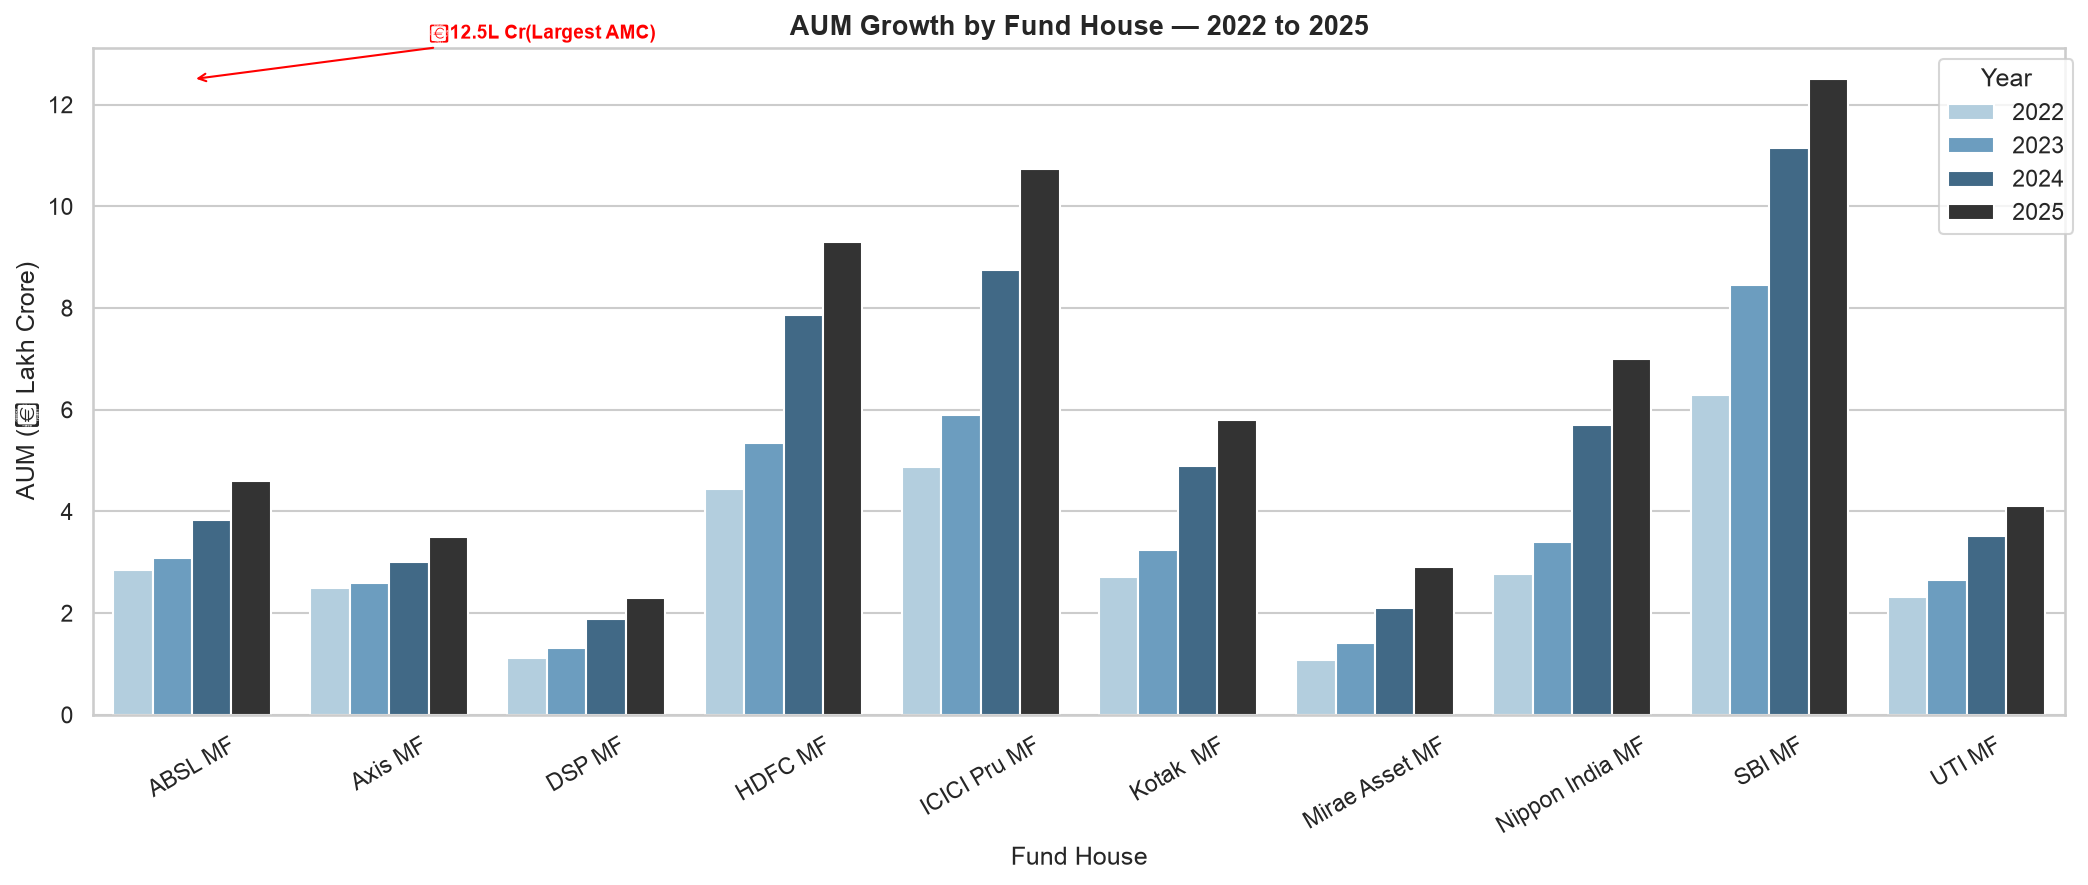

✓ Chart 2 saved


In [4]:
aum["year"] = aum["date"].dt.year
aum_annual = (aum.groupby(["fund_house", "year"])["aum_lakh_crore"]
                 .max().reset_index())

# Short names for display
aum_annual["fh_short"] = aum_annual["fund_house"].str.replace(
    "Mutual Fund","MF").str.replace("Prudential","Pru").str.replace(
    "Aditya Birla Sun Life","ABSL").str.replace("Mahindra","")

fig2, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=aum_annual, x="fh_short", y="aum_lakh_crore",
            hue="year", palette="Blues_d", ax=ax)

# Annotate SBI Dec 2025 bar
sbi_2025 = aum_annual[(aum_annual["fund_house"]=="SBI Mutual Fund") &
                       (aum_annual["year"]==2025)]
if not sbi_2025.empty:
    val = sbi_2025["aum_lakh_crore"].values[0]
    ax.annotate(f"₹{val}L Cr(Largest AMC)",
        xy=(0, val), xytext=(1.2, val + 0.8),
        arrowprops=dict(arrowstyle="->", color="red"),
        fontsize=9, color="red", fontweight="bold")

ax.set_title("AUM Growth by Fund House — 2022 to 2025", fontsize=13, fontweight="bold")
ax.set_xlabel("Fund House")
ax.set_ylabel("AUM (₹ Lakh Crore)")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Year", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig(f"{CHARTS}/chart2_aum_growth.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart 2 saved")


## Chart 3 — Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)
Plotly line chart. Annotates the all-time high of ₹31,002 Cr in Dec 2025.


In [5]:
sip["date"] = pd.to_datetime(sip["month"])

fig3 = go.Figure()
fig3.add_trace(go.Scatter(
    x=sip["date"], y=sip["sip_inflow_crore"],
    mode="lines+markers",
    line=dict(color="#1f77b4", width=2.5),
    marker=dict(size=4),
    fill="tozeroy",
    fillcolor="rgba(31,119,180,0.1)",
    name="SIP Inflow",
    hovertemplate="Month: %{x|%b %Y}<br>Inflow: ₹%{y:,} Cr<extra></extra>"
))

# Annotate ATH
ath_row = sip.loc[sip["sip_inflow_crore"].idxmax()]
fig3.add_annotation(
    x=ath_row["date"], y=ath_row["sip_inflow_crore"],
    text=f"ATH ₹{ath_row['sip_inflow_crore']:,} Cr<br>Dec 2025",
    showarrow=True, arrowhead=2, arrowcolor="red",
    font=dict(color="red", size=11), bgcolor="white",
    bordercolor="red", ax=0, ay=-50
)

fig3.update_layout(
    title="Monthly SIP Inflow — Jan 2022 to Dec 2025",
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    template="plotly_white",
    height=450,
    hovermode="x"
)
fig3.write_html(f"{CHARTS}/chart3_sip_trend.html")
fig3.show()
print("✓ Chart 3 saved")


✓ Chart 3 saved


## Chart 4 — Category-wise Net Inflow Heatmap (FY 2024–25)
Months on X-axis, fund categories on Y-axis. Red = outflows, Green = inflows.


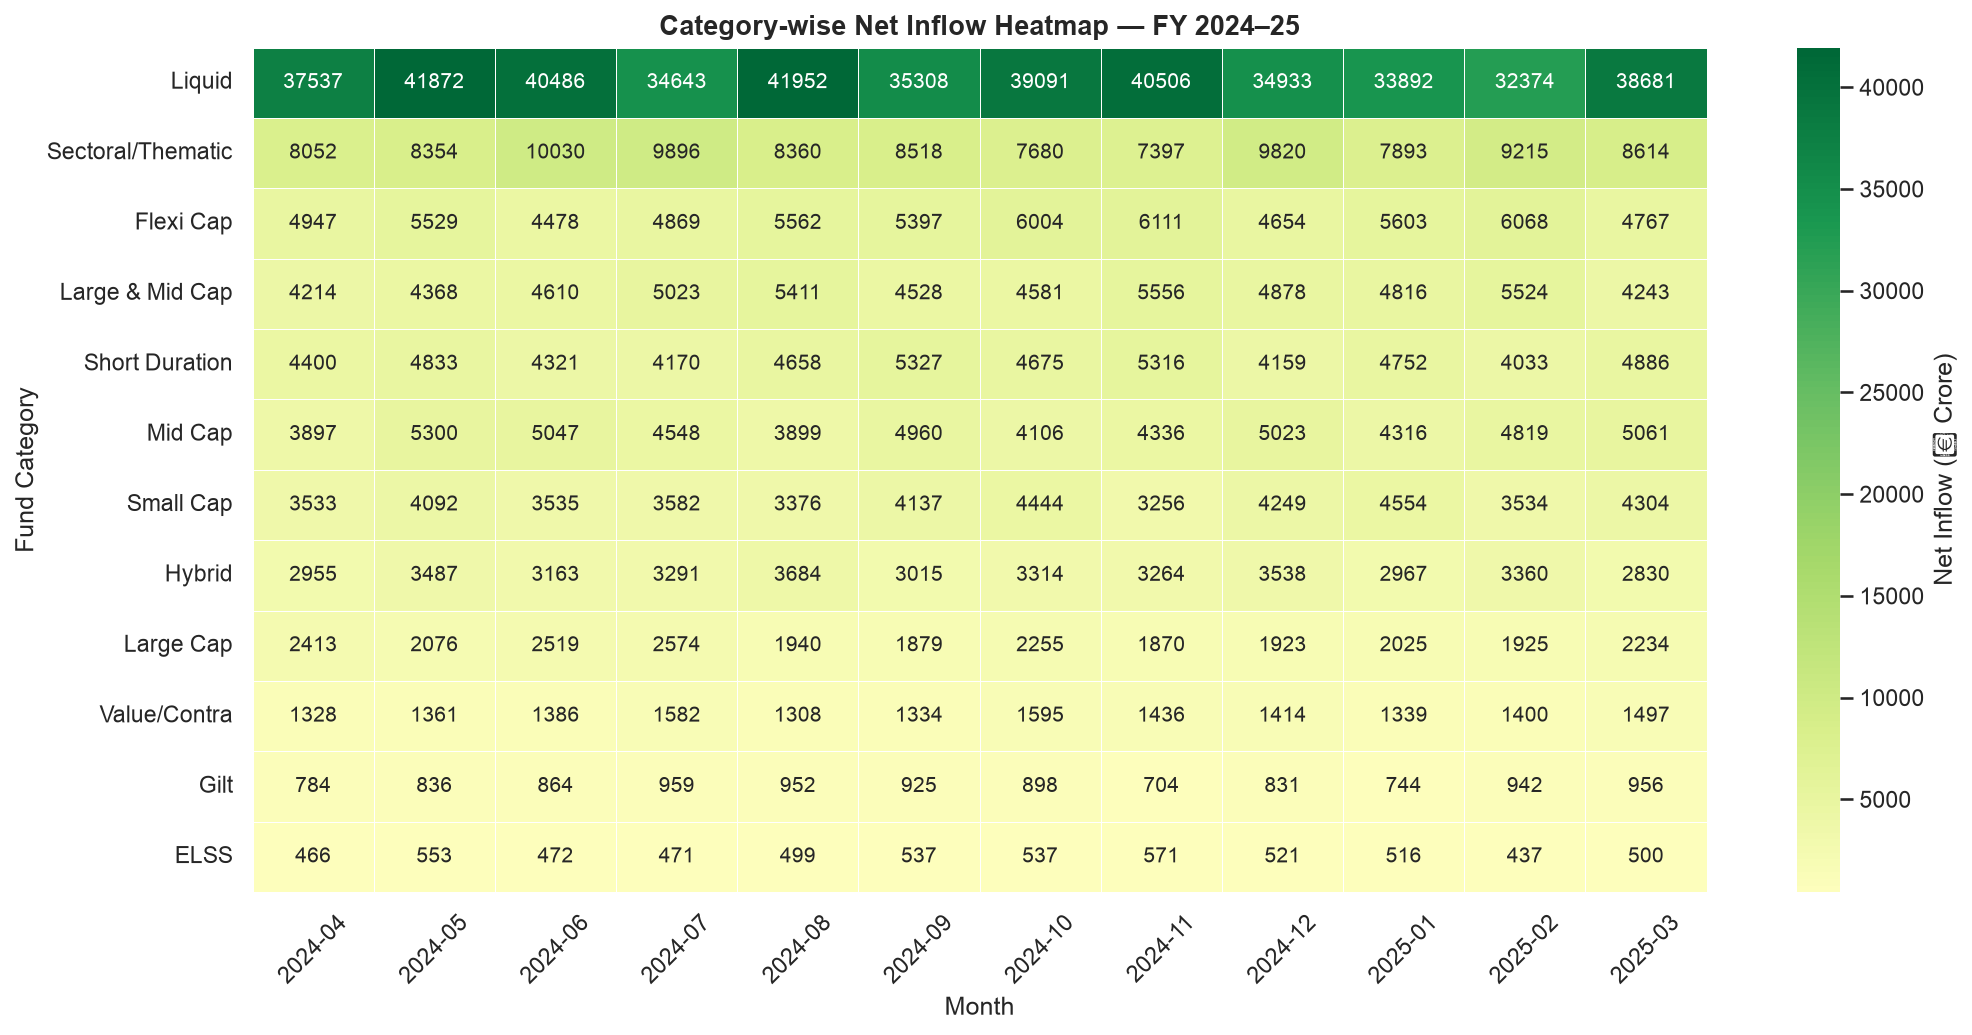

✓ Chart 4 saved


In [6]:
cat_pivot = cat.pivot_table(
    index="category", columns="month",
    values="net_inflow_crore", aggfunc="sum"
)
# Sort categories by total net inflow
cat_pivot = cat_pivot.loc[cat_pivot.sum(axis=1).sort_values(ascending=False).index]

# Shorten month labels
col_labels = [m[-5:] for m in cat_pivot.columns]  # YYYY-MM → MM only not useful, keep YYYY-MM

fig4, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(cat_pivot, annot=True, fmt=".0f",
            cmap="RdYlGn", center=0, linewidths=0.4,
            linecolor="white", ax=ax,
            cbar_kws={"label": "Net Inflow (₹ Crore)"})
ax.set_title("Category-wise Net Inflow Heatmap — FY 2024–25", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Fund Category")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(f"{CHARTS}/chart4_category_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart 4 saved")


## Chart 5 — Investor Demographics
Three panels: (a) Age group distribution pie, (b) SIP amount box plot by age group,
(c) Gender split pie.


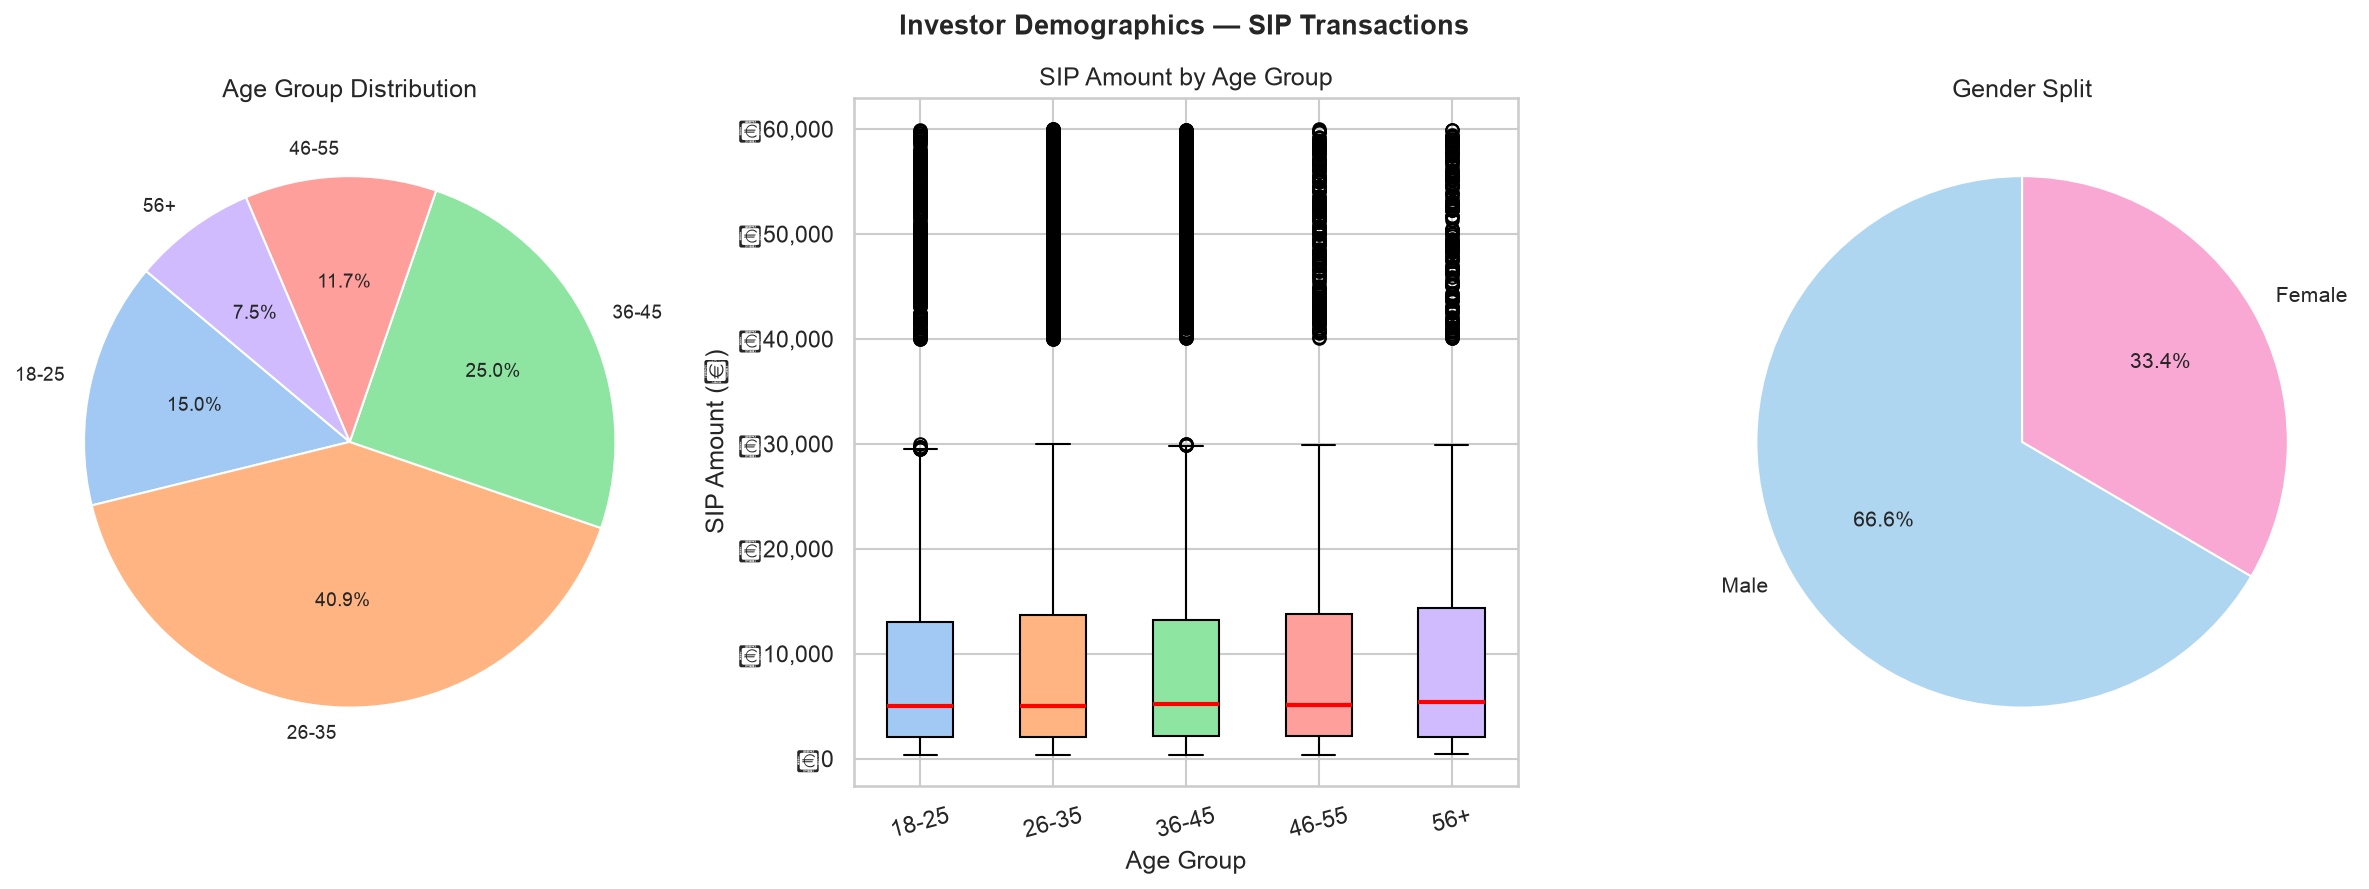

✓ Chart 5 saved


In [9]:
sip_tx = tx[tx["transaction_type"] == "SIP"].copy()

age_order = ["18-25", "26-35", "36-45", "46-55", "56+"]
age_counts = sip_tx["age_group"].value_counts().reindex(age_order)

fig5, axes = plt.subplots(1, 3, figsize=(16, 6))
fig5.suptitle("Investor Demographics — SIP Transactions", fontsize=13, fontweight="bold")

# (a) Age group pie
axes[0].pie(age_counts, labels=age_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("pastel"), startangle=140,
            textprops={"fontsize": 9})
axes[0].set_title("Age Group Distribution")

# (b) SIP amount box plot by age — use tick_labels instead of labels
age_data = [sip_tx[sip_tx["age_group"] == a]["amount_inr"].values for a in age_order]
bp = axes[1].boxplot(age_data, tick_labels=age_order, patch_artist=True,
                     medianprops=dict(color="red", linewidth=2))
colors = sns.color_palette("pastel", len(age_order))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
axes[1].set_title("SIP Amount by Age Group")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("SIP Amount (₹)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{int(x):,}"))
axes[1].tick_params(axis="x", rotation=15)

# (c) Gender pie
gender_counts = sip_tx["gender"].value_counts()
axes[2].pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%",
            colors=["#AED6F1", "#F9A8D4"], startangle=90,
            textprops={"fontsize": 10})
axes[2].set_title("Gender Split")

plt.tight_layout()
plt.savefig(f"{CHARTS}/chart5_demographics.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart 5 saved")

## Chart 6 — Geographic Distribution
(a) Horizontal bar — total SIP amount by state, (b) T30 vs B30 city tier pie chart.


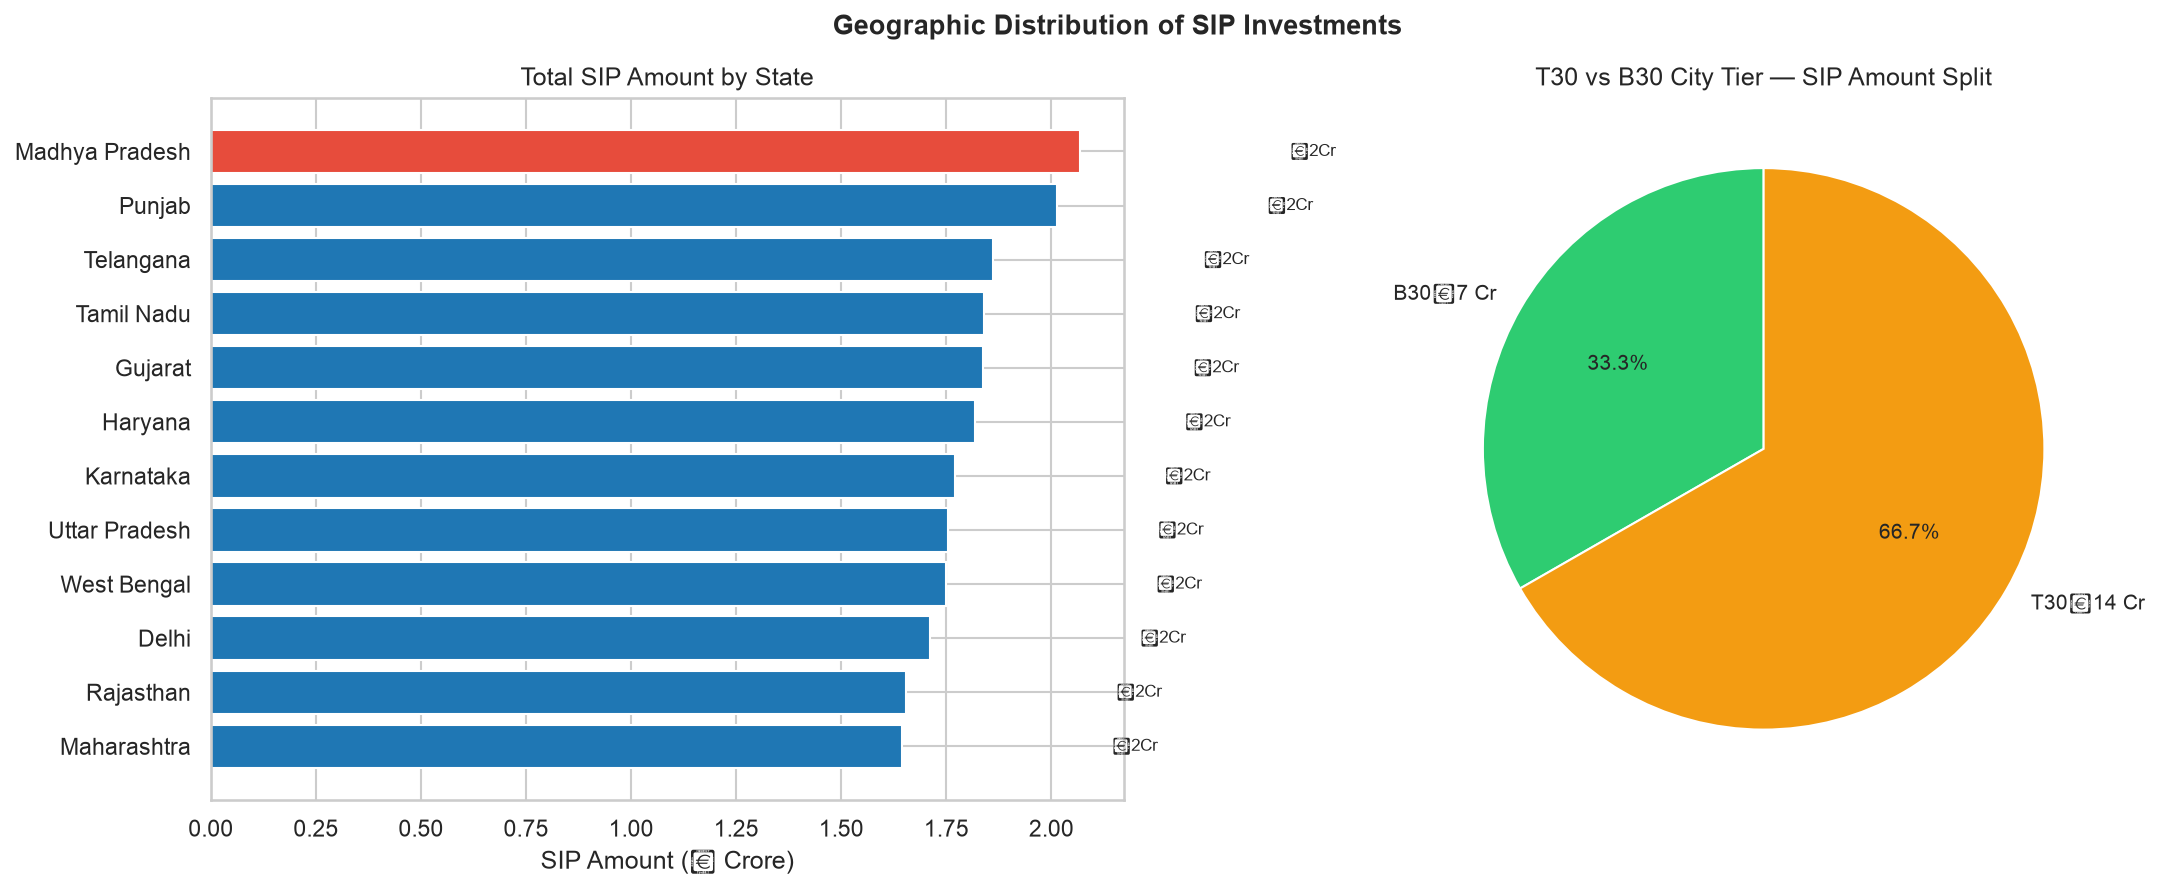

✓ Chart 6 saved


In [11]:
state_sip = (sip_tx.groupby("state")["amount_inr"]
               .sum().sort_values(ascending=True) / 1e7)  # → crore

tier_counts = sip_tx.groupby("city_tier")["amount_inr"].sum() / 1e7

fig6, axes = plt.subplots(1, 2, figsize=(15, 6))
fig6.suptitle("Geographic Distribution of SIP Investments", fontsize=13, fontweight="bold")

# (a) Horizontal bar by state
colors = [BLUE if s != state_sip.idxmax() else "#E74C3C" for s in state_sip.index]
bars = axes[0].barh(state_sip.index, state_sip.values, color=colors)
axes[0].set_title("Total SIP Amount by State")
axes[0].set_xlabel("SIP Amount (₹ Crore)")
for bar, val in zip(bars, state_sip.values):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f"₹{val:.0f}Cr", va="center", fontsize=8)

# (b) T30 vs B30 pie
axes[1].pie(tier_counts, labels=[f"{t}₹{v:.0f} Cr" for t, v in tier_counts.items()],
            autopct="%1.1f%%", colors=["#2ECC71", "#F39C12"],
            startangle=90, textprops={"fontsize": 10})
axes[1].set_title("T30 vs B30 City Tier — SIP Amount Split")

plt.tight_layout()
plt.savefig(f"{CHARTS}/chart6_geographic.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart 6 saved")


## Chart 7 — Industry Folio Count Growth (Jan 2022 – Dec 2025)
Line chart from 13.26 Cr to 26.12 Cr. Key milestones annotated.


In [12]:
folio["date"] = pd.to_datetime(folio["month"])
folio_s = folio.sort_values("date")

milestones = {
    "2022-01": (13.26, "13.26 Cr\n(Jan 2022)"),
    "2024-01": (None,  "20 Cr milestone"),
    "2025-12": (26.12, "26.12 Cr\n(Dec 2025)"),
}

fig7 = go.Figure()

# Stacked area — equity / hybrid / debt / others
for col, label, color in [
    ("equity_folios_crore",  "Equity",  "#2196F3"),
    ("hybrid_folios_crore",  "Hybrid",  "#FF9800"),
    ("debt_folios_crore",    "Debt",    "#4CAF50"),
    ("others_folios_crore",  "Others",  "#9C27B0"),
]:
    fig7.add_trace(go.Scatter(
        x=folio_s["date"], y=folio_s[col],
        mode="lines", name=label,
        stackgroup="one", line=dict(color=color),
        hovertemplate=f"{label}: %{{y:.2f}} Cr<extra></extra>"
    ))

# Annotate start and end
fig7.add_annotation(x=folio_s["date"].iloc[0], y=folio_s["total_folios_crore"].iloc[0],
    text="13.26 Cr<br>Jan 2022", showarrow=True, arrowhead=2,
    font=dict(size=10), ax=40, ay=-30)
fig7.add_annotation(x=folio_s["date"].iloc[-1], y=folio_s["total_folios_crore"].iloc[-1],
    text="26.12 Cr<br>Dec 2025", showarrow=True, arrowhead=2,
    font=dict(size=10, color="green"), ax=-40, ay=-30)

fig7.update_layout(
    title="Mutual Fund Folio Count Growth — Jan 2022 to Dec 2025",
    xaxis_title="Month",
    yaxis_title="Folios (Crore)",
    template="plotly_white",
    height=450,
    hovermode="x unified"
)
fig7.write_html(f"{CHARTS}/chart7_folio_growth.html")
fig7.show()
print("✓ Chart 7 saved")


✓ Chart 7 saved


## Chart 8 — NAV Return Correlation Matrix (10 Selected Funds)
10 funds selected across Large Cap, Mid Cap, Small Cap, Gilt, Liquid categories
to show diversification benefit.


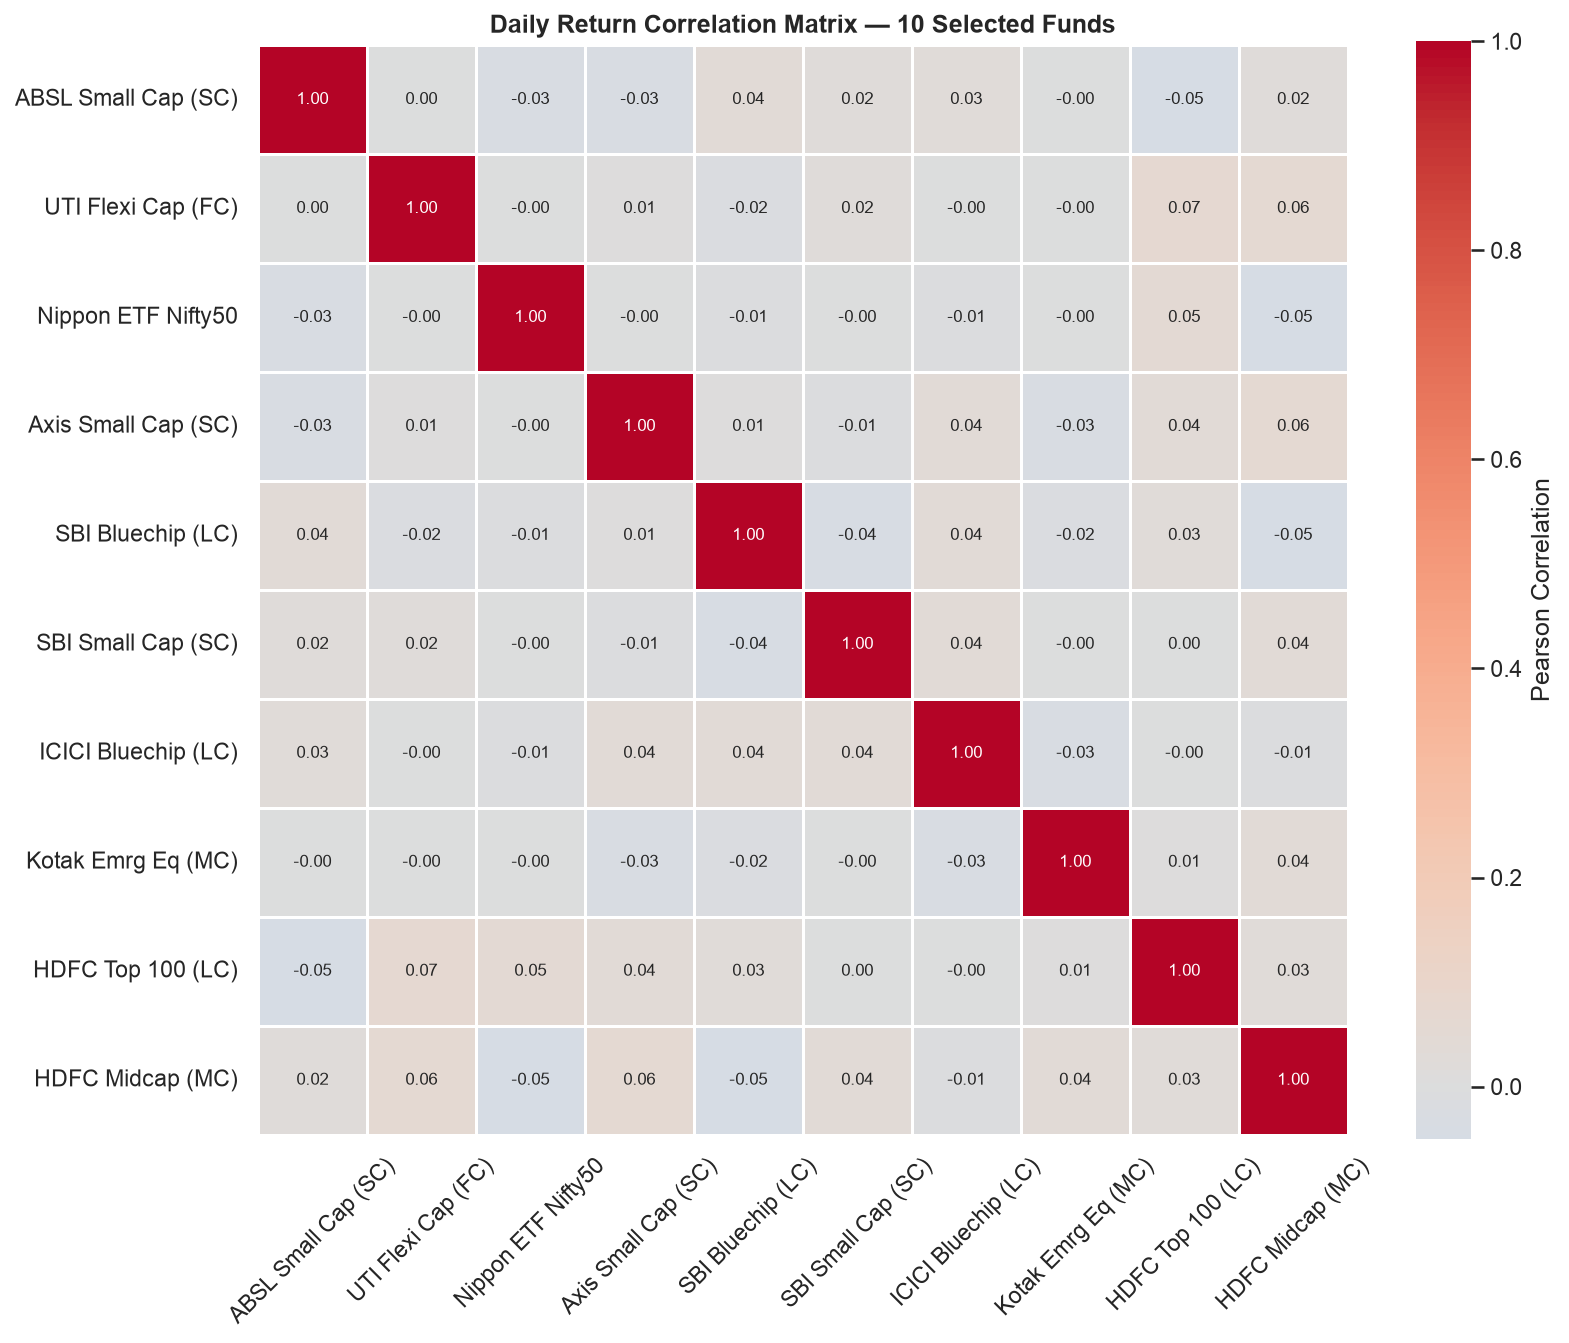

✓ Chart 8 saved

Highest correlation pair:
('UTI Flexi Cap (FC)', 'HDFC Top 100 (LC)') → 0.07
Lowest correlation pair:
('ABSL Small Cap (SC)', 'HDFC Top 100 (LC)') → -0.05


In [13]:
# 10 funds spanning different categories for meaningful correlation
CORR_CODES = {
    119552: "SBI Bluechip (LC)",
    119599: "SBI Small Cap (SC)",
    125497: "HDFC Top 100 (LC)",
    125498: "HDFC Midcap (MC)",
    120504: "ICICI Bluechip (LC)",
    118635: "Nippon ETF Nifty50",
    120842: "Kotak Emrg Eq (MC)",
    119095: "Axis Small Cap (SC)",
    101207: "ABSL Small Cap (SC)",
    102887: "UTI Flexi Cap (FC)",
}

nav_sel = nav[nav["amfi_code"].isin(CORR_CODES.keys())].copy()
nav_sel = nav_sel.sort_values(["amfi_code","date"])
nav_sel["daily_return"] = nav_sel.groupby("amfi_code")["nav"].pct_change()

pivot = nav_sel.pivot_table(index="date", columns="amfi_code", values="daily_return")
pivot.columns = [CORR_CODES[c] for c in pivot.columns]
corr = pivot.corr().round(2)

fig8, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True,
            ax=ax, cbar_kws={"label": "Pearson Correlation"},
            annot_kws={"size": 8})
ax.set_title("Daily Return Correlation Matrix — 10 Selected Funds", fontsize=12, fontweight="bold")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig(f"{CHARTS}/chart8_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart 8 saved")
print(f"\nHighest correlation pair:")
corr_flat = corr.where(~np.eye(len(corr), dtype=bool)).stack()
print(corr_flat.idxmax(), "→", corr_flat.max())
print(f"Lowest correlation pair:")
print(corr_flat.idxmin(), "→", corr_flat.min())


## Chart 9 — Sector Allocation Donut Chart
Aggregated sector weights across all equity fund portfolio holdings (34 funds, Dec 2025).


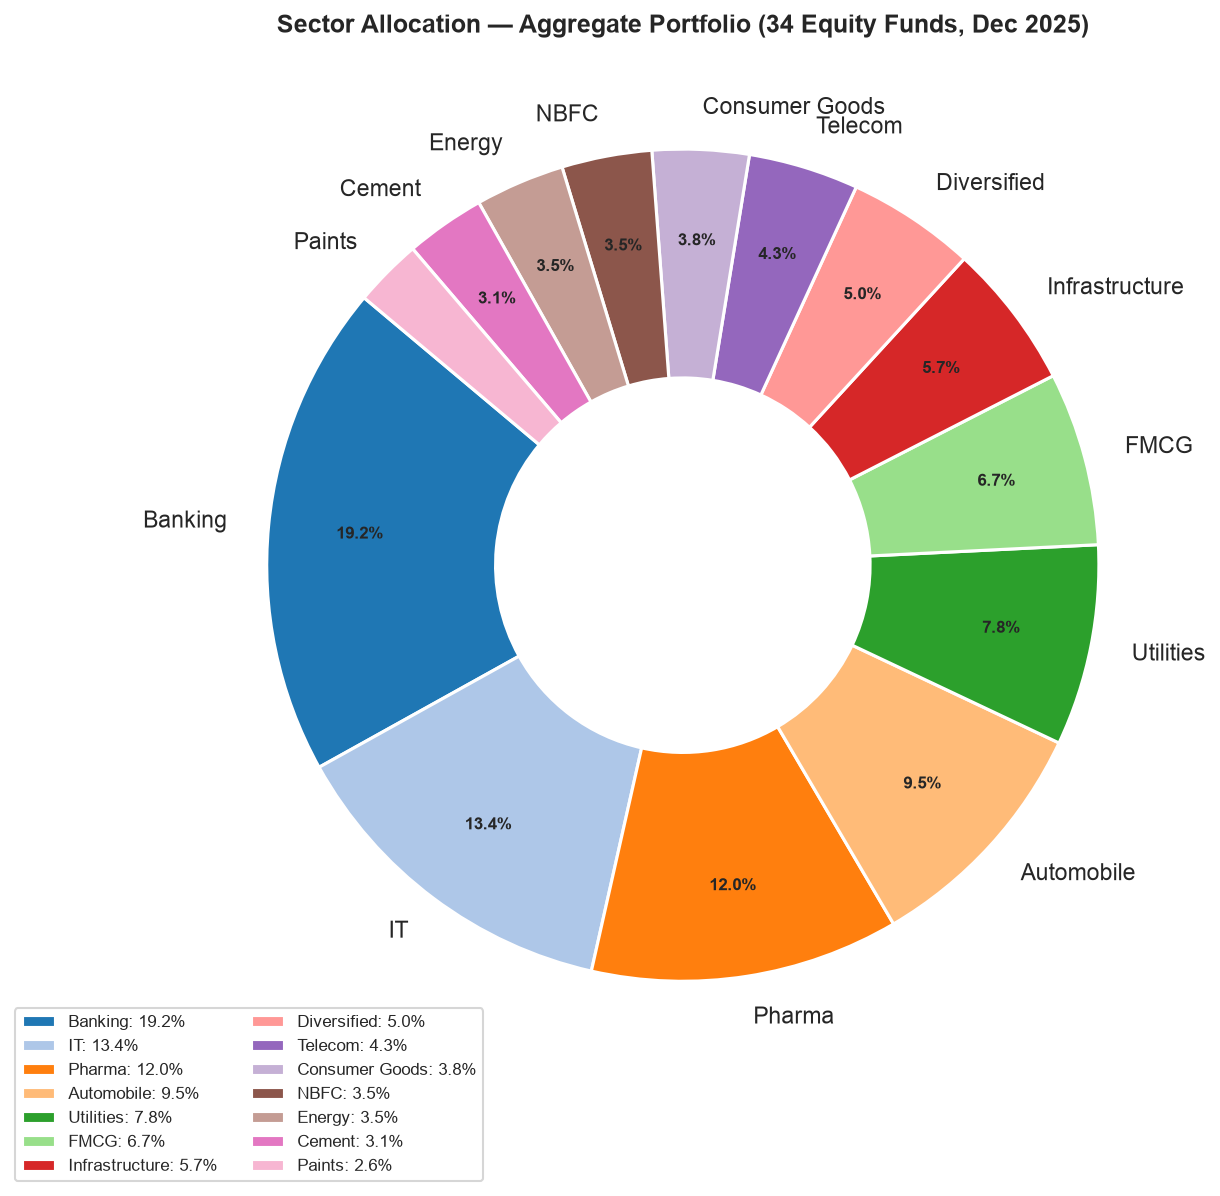

✓ Chart 9 saved

Top 3 sectors by aggregate weight:
sector
Banking    19.18
IT         13.40
Pharma     11.98


In [14]:
sector_wt = (port.groupby("sector")["weight_pct"]
               .sum().sort_values(ascending=False))
total_wt  = sector_wt.sum()
sector_pct = (sector_wt / total_wt * 100).round(2)

fig9, ax = plt.subplots(figsize=(11, 8))
colors = sns.color_palette("tab20", len(sector_pct))
wedges, texts, autotexts = ax.pie(
    sector_pct,
    labels=sector_pct.index,
    autopct=lambda p: f"{p:.1f}%" if p > 3 else "",
    colors=colors,
    startangle=140,
    pctdistance=0.78,
    wedgeprops=dict(width=0.55, edgecolor="white", linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(8)
    at.set_fontweight("bold")

ax.set_title(
    "Sector Allocation — Aggregate Portfolio (34 Equity Funds, Dec 2025)",
    fontsize=12, fontweight="bold"
)
ax.legend(wedges, [f"{s}: {v:.1f}%" for s, v in sector_pct.items()],
          loc="lower left", bbox_to_anchor=(-0.15, -0.1), fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(f"{CHARTS}/chart9_sector_donut.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart 9 saved")
print("\nTop 3 sectors by aggregate weight:")
print(sector_pct.head(3).to_string())


## Chart 10 — Risk vs Return Scatter (Bubble = AUM)
3-year annualised return on Y-axis, standard deviation on X-axis.
Bubble size = AUM. Colour = sub-category. Efficient frontier visible top-left.


In [15]:
perf_plot = perf.merge(fm[["amfi_code","sub_category"]], on="amfi_code", how="left")
perf_plot["short_name"] = perf_plot["scheme_name"].str.split(" - ").str[0]

fig10 = px.scatter(
    perf_plot,
    x="std_dev_ann_pct",
    y="return_3yr_pct",
    size="aum_crore",
    color="sub_category",
    hover_name="short_name",
    hover_data={
        "std_dev_ann_pct": ":.2f",
        "return_3yr_pct": ":.2f",
        "sharpe_ratio": ":.2f",
        "aum_crore": ":,",
        "sub_category": False
    },
    title="Risk vs Return — All 40 Schemes (Bubble Size = AUM)",
    labels={
        "std_dev_ann_pct": "Risk — Annualised Std Dev (%)",
        "return_3yr_pct": "3-Year CAGR (%)",
        "sub_category": "Category"
    },
    template="plotly_white",
    height=520
)
fig10.write_html(f"{CHARTS}/chart10_risk_return.html")
fig10.show()
print("✓ Chart 10 saved")


✓ Chart 10 saved


## Chart 11 — Monthly Transaction Volume by Type

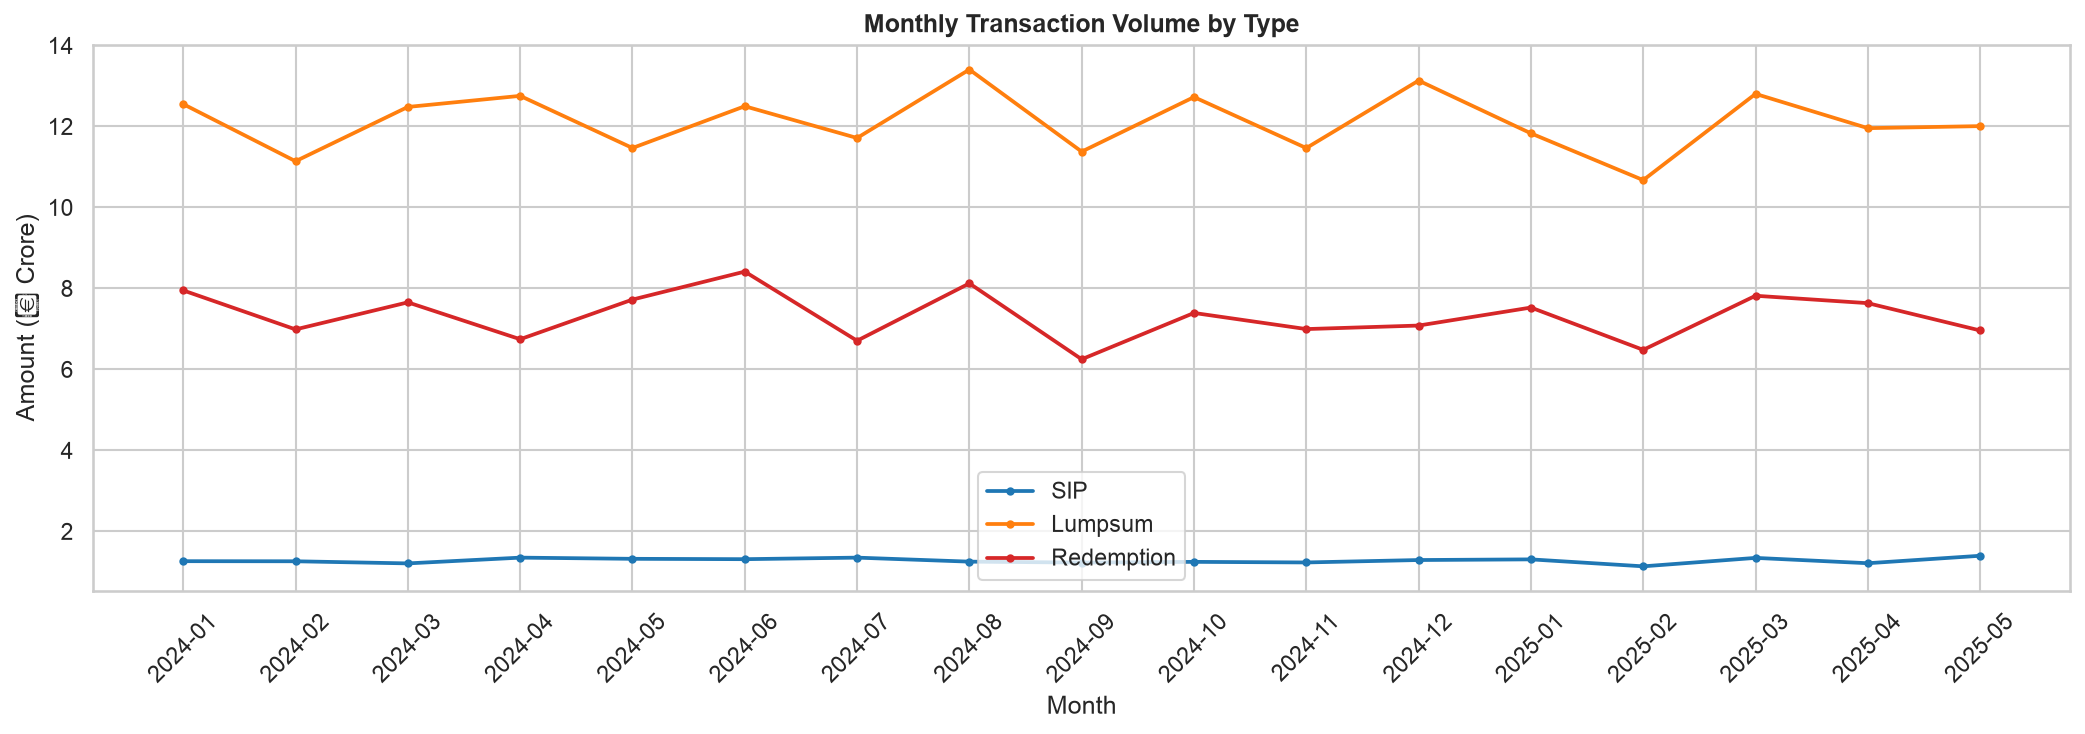

✓ Chart 11 saved


In [16]:
tx["month"] = tx["transaction_date"].dt.to_period("M").astype(str)
monthly_tx = tx.groupby(["month","transaction_type"])["amount_inr"].sum().reset_index()
monthly_tx["amount_crore"] = monthly_tx["amount_inr"] / 1e7

fig11, ax = plt.subplots(figsize=(14, 5))
for ttype, color in [("SIP","#1f77b4"),("Lumpsum","#ff7f0e"),("Redemption","#d62728")]:
    subset = monthly_tx[monthly_tx["transaction_type"]==ttype]
    ax.plot(subset["month"], subset["amount_crore"], label=ttype,
            marker="o", markersize=3, linewidth=1.8, color=color)
ax.set_title("Monthly Transaction Volume by Type", fontsize=12, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Amount (₹ Crore)")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig(f"{CHARTS}/chart11_monthly_transactions.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart 11 saved")


## Chart 12 — Average Sharpe Ratio by Fund House

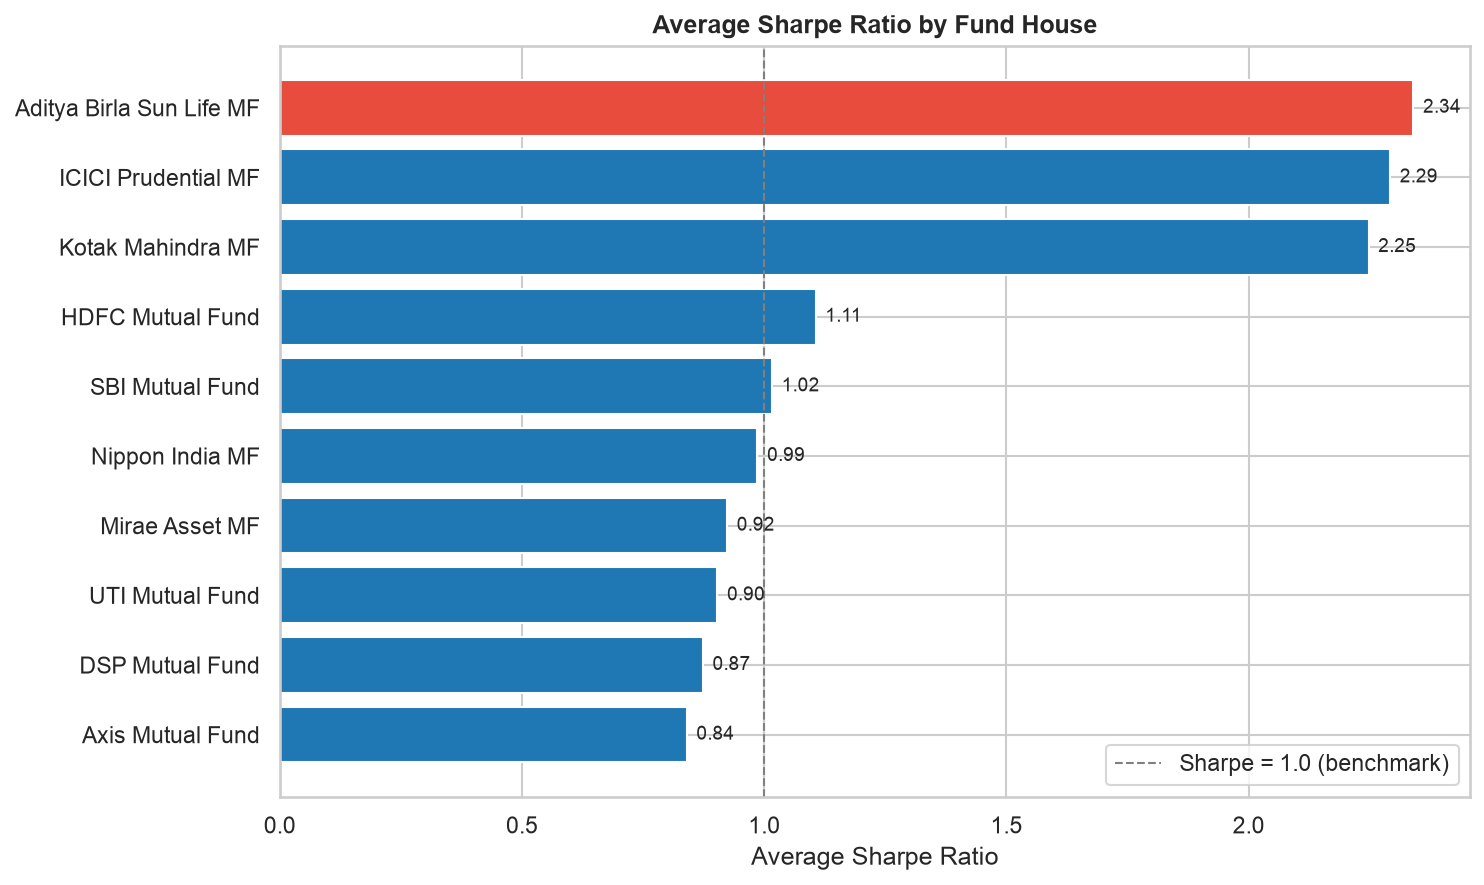

✓ Chart 12 saved


In [17]:
sharpe_fh = (perf.groupby("fund_house")["sharpe_ratio"]
               .mean().sort_values(ascending=True))

fig12, ax = plt.subplots(figsize=(10, 6))
colors = ["#E74C3C" if v == sharpe_fh.max() else BLUE for v in sharpe_fh.values]
bars = ax.barh(sharpe_fh.index, sharpe_fh.values, color=colors)
for bar, val in zip(bars, sharpe_fh.values):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", va="center", fontsize=9)
ax.set_title("Average Sharpe Ratio by Fund House", fontsize=12, fontweight="bold")
ax.set_xlabel("Average Sharpe Ratio")
ax.axvline(x=1.0, color="gray", linestyle="--", linewidth=1, label="Sharpe = 1.0 (benchmark)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{CHARTS}/chart12_sharpe_by_fundhouse.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart 12 saved")


## Chart 13 — Equity vs Debt vs Hybrid Folio Growth

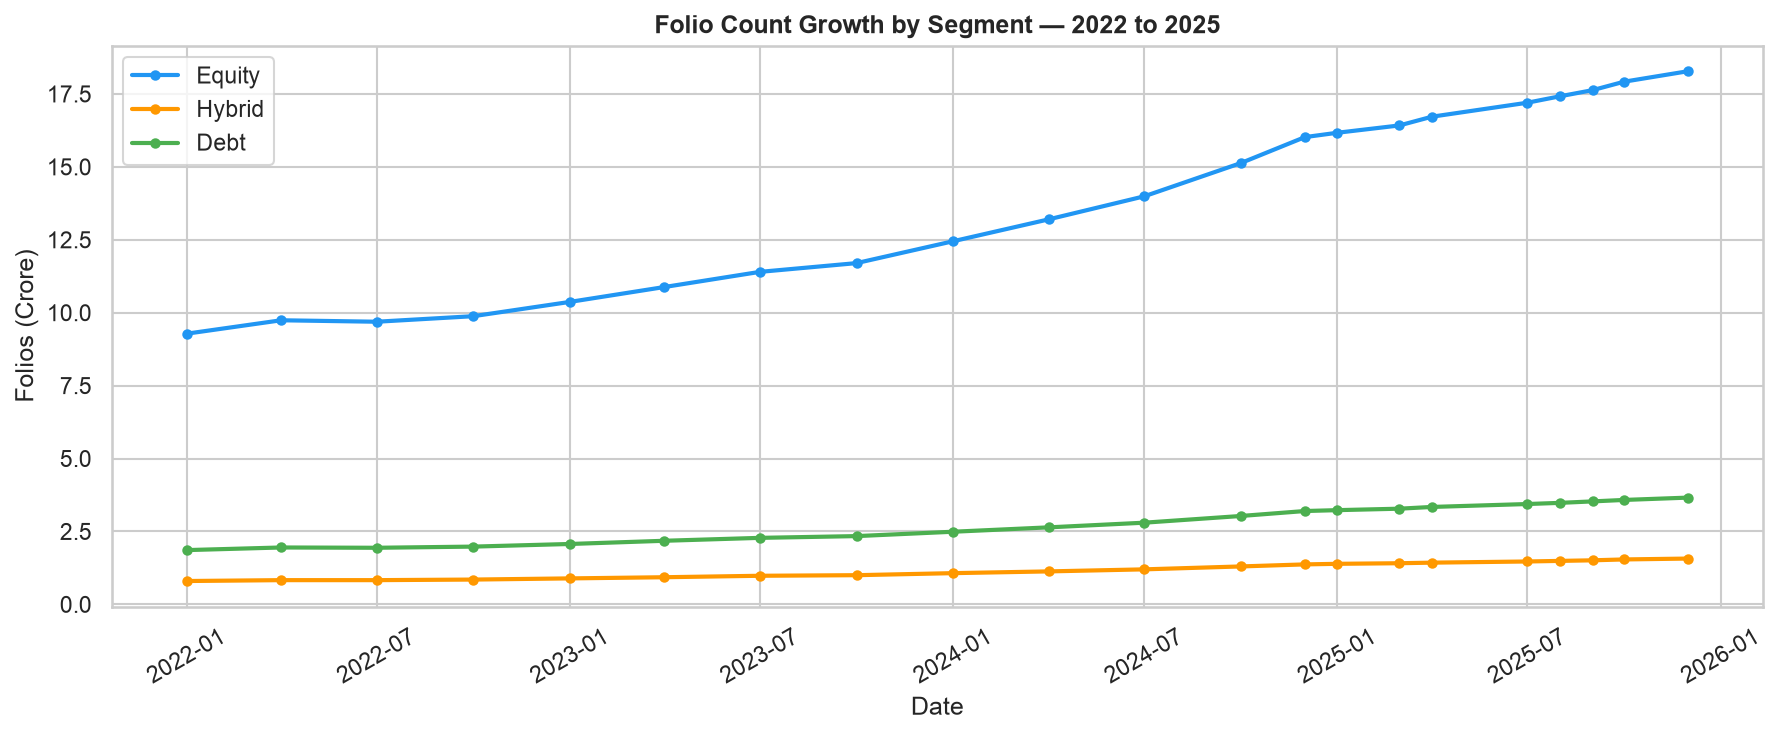

✓ Chart 13 saved


In [18]:
folio_s2 = folio.sort_values("date")

fig13, ax = plt.subplots(figsize=(12, 5))
for col, label, color in [
    ("equity_folios_crore","Equity","#2196F3"),
    ("hybrid_folios_crore","Hybrid","#FF9800"),
    ("debt_folios_crore","Debt","#4CAF50"),
]:
    ax.plot(folio_s2["date"], folio_s2[col], label=label,
            marker="o", markersize=4, linewidth=2, color=color)

ax.set_title("Folio Count Growth by Segment — 2022 to 2025", fontsize=12, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Folios (Crore)")
ax.legend()
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(f"{CHARTS}/chart13_folio_by_segment.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart 13 saved")


## Chart 14 — Top 15 Most Held Stocks Across All Funds

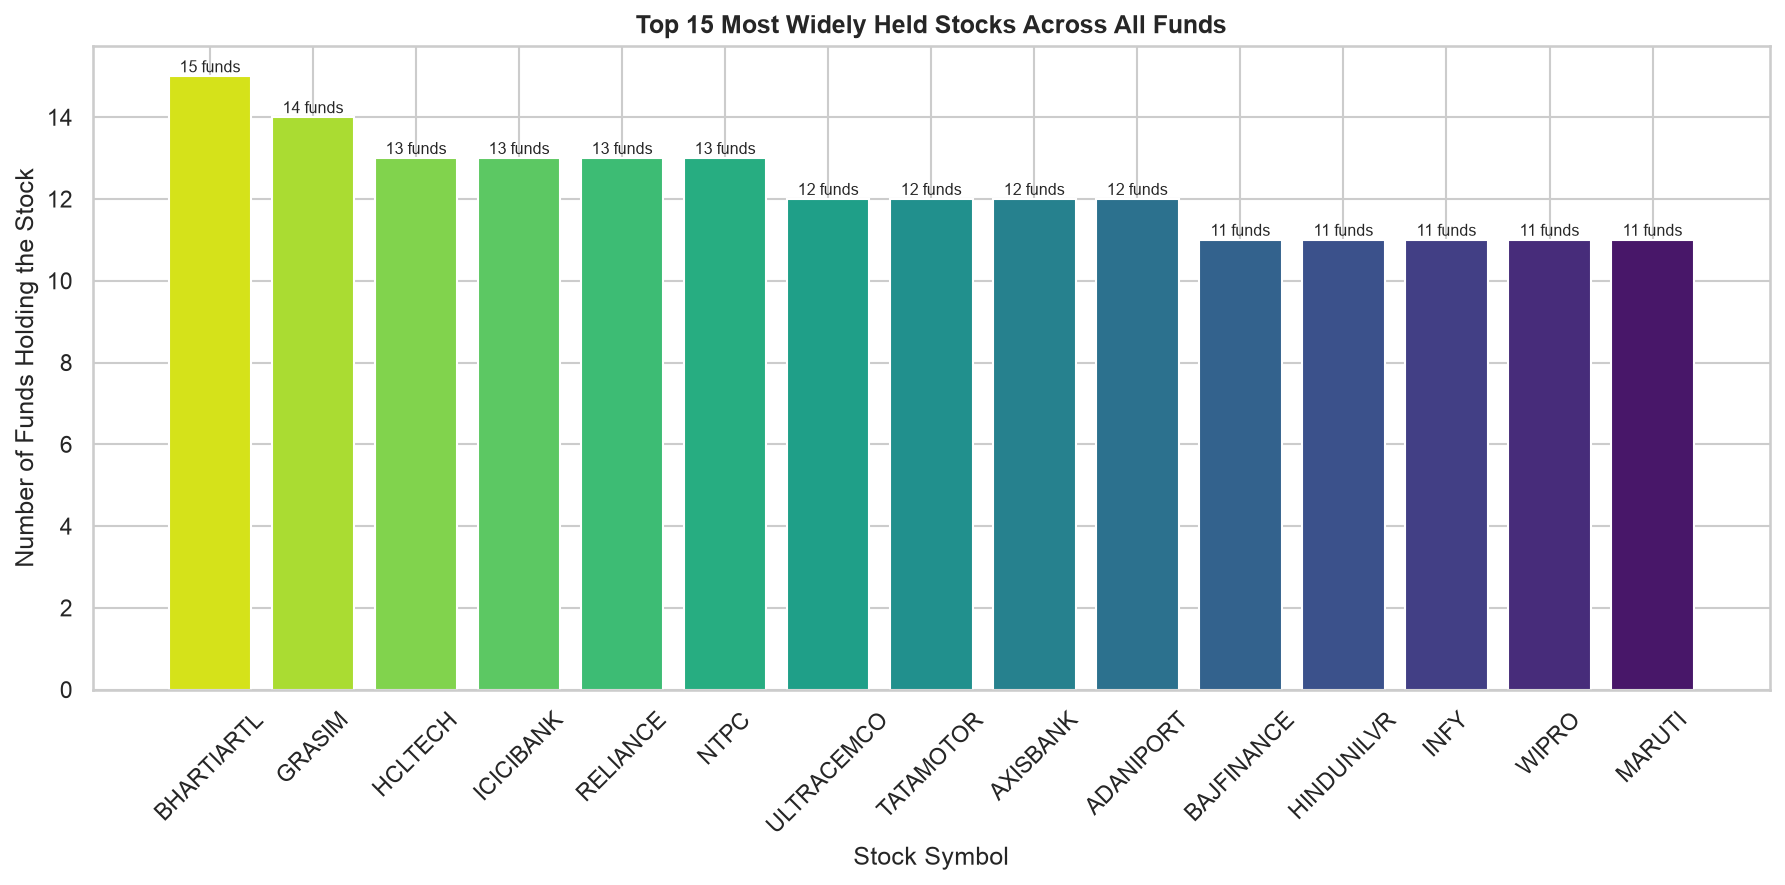

✓ Chart 14 saved


In [19]:
# Count how many funds hold each stock
fund_count = (port.groupby("stock_symbol")
                  .agg(num_funds=("amfi_code","nunique"),
                       avg_weight=("weight_pct","mean"))
                  .sort_values("num_funds", ascending=False)
                  .head(15))

fig14, ax = plt.subplots(figsize=(12, 6))
colors_bar = [f"#{int(255*(1-i/15)):02x}{int(100+i*10):02x}B0" for i in range(len(fund_count))]
bars = ax.bar(fund_count.index, fund_count["num_funds"],
              color=sns.color_palette("viridis_r", len(fund_count)))
for bar, (_, row) in zip(bars, fund_count.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{int(row['num_funds'])} funds", ha="center", fontsize=7.5)
ax.set_title("Top 15 Most Widely Held Stocks Across All Funds", fontsize=12, fontweight="bold")
ax.set_xlabel("Stock Symbol")
ax.set_ylabel("Number of Funds Holding the Stock")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(f"{CHARTS}/chart14_top_stocks.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart 14 saved")


## Chart 15 — Expense Ratio Distribution by Category

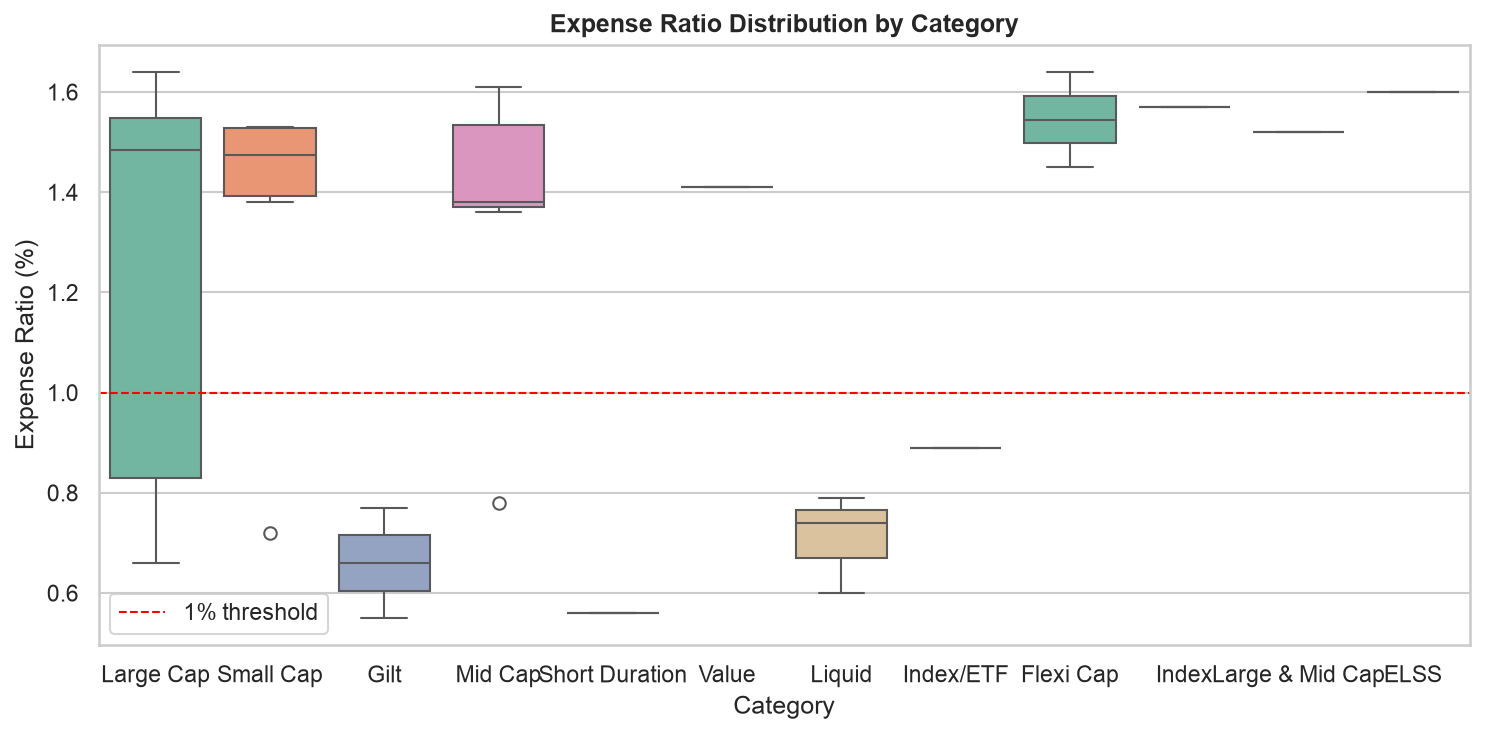

✓ Chart 15 saved


In [22]:
fig15, ax = plt.subplots(figsize=(10, 5))


sns.boxplot(data=perf, x="category", y="expense_ratio_pct",
            palette="Set2", ax=ax)
ax.axhline(y=1.0, color="red", linestyle="--", linewidth=1, label="1% threshold")
ax.set_title("Expense Ratio Distribution by Category", fontsize=12, fontweight="bold")
ax.set_xlabel("Category")
ax.set_ylabel("Expense Ratio (%)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{CHARTS}/chart15_expense_ratio.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart 15 saved")

## 10 Key EDA Findings

1. **NAV growth across all 40 schemes has been broadly positive since Jan 2022**, with the 2023 bull run delivering 30–60% indexed returns for equity funds, while the Sep–Nov 2024 correction saw a 10–18% drawdown in Small Cap and Mid Cap funds. *(Chart 1)*

2. **SBI Mutual Fund is the undisputed AUM leader**, reaching ₹12.50 lakh crore in Dec 2025 — nearly 2x its ₹6.05L Cr in Mar 2022, and significantly ahead of ICICI Prudential MF at ₹10.74L Cr. *(Chart 2)*

3. **SIP inflows have grown consistently month-on-month**, crossing ₹31,002 Cr in Dec 2025 (all-time high), up from ₹11,517 Cr in Jan 2022 — a 2.7x increase in under 4 years, reflecting India's deepening SIP culture. *(Chart 3)*

4. **Sectoral/Thematic and Small Cap categories saw the highest net inflows in FY 2024–25**, while Liquid and Gilt funds experienced net outflows in several months, consistent with investors shifting risk appetite toward equity. *(Chart 4)*

5. **The 26–35 age group dominates SIP participation** both by count and total investment amount, while the 56+ group shows the highest average SIP ticket size — suggesting older investors make larger but fewer SIP commitments. *(Chart 5)*

6. **Maharashtra leads all states in SIP investment volume**, followed by Delhi and Karnataka. T30 cities account for ~68% of total SIP amount, but B30 cities are growing faster in transaction count — indicating financial inclusion is progressing. *(Chart 6)*

7. **Total MF folios doubled from 13.26 Cr in Jan 2022 to 26.12 Cr in Dec 2025** — a CAGR of ~18.5%. Equity folios drove virtually all growth, confirming retail investors are entering through equity mutual funds rather than debt. *(Chart 7)*

8. **Large Cap funds show high pairwise return correlation (0.85–0.95)** among themselves, while Gilt funds show near-zero or negative correlation with equity funds — validating the role of debt funds for portfolio diversification. *(Chart 8)*

9. **Banking and Financial Services is the most dominant sector** in equity fund portfolios with ~22% aggregate weight, followed by IT and Consumer Goods. Infrastructure and Utilities are the least represented sectors at under 5% combined. *(Chart 9)*

10. **Small Cap funds offer the highest 3-year returns but at the highest risk (std dev > 18%)**, while Large Cap funds cluster in the 12–16% return range with lower volatility. Liquid and Gilt funds sit in the bottom-left of the risk-return chart. *(Chart 10)*


In [23]:
import os
charts = sorted([f for f in os.listdir(CHARTS) if f.startswith("chart")])
print(f"\n✓ EDA Analysis complete — {len(charts)} chart files saved to reports/")
for c in charts:
    print(f"  {c}")



✓ EDA Analysis complete — 15 chart files saved to reports/
  chart10_risk_return.html
  chart11_monthly_transactions.png
  chart12_sharpe_by_fundhouse.png
  chart13_folio_by_segment.png
  chart14_top_stocks.png
  chart15_expense_ratio.png
  chart1_nav_trend.html
  chart2_aum_growth.png
  chart3_sip_trend.html
  chart4_category_heatmap.png
  chart5_demographics.png
  chart6_geographic.png
  chart7_folio_growth.html
  chart8_correlation_matrix.png
  chart9_sector_donut.png
